# Message Intelligence System

### prt B : Dataset understangding & preparation 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Message Intelligence Dataset.csv")

df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [5]:
print("Shape :", df.shape)

Shape : (5200, 16)


In [6]:
print("\nColumns")
print(df.columns)


Columns
Index(['message_id', 'message_text', 'message_length', 'word_count',
       'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score',
       'legit_keyword_score', 'sender_activity_score',
       'sender_account_age_days', 'messages_sent_last_24h', 'timestamp',
       'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='object')


In [7]:
df.dtypes

message_id                   int64
message_text                object
message_length               int64
word_count                   int64
num_urls                     int64
num_digits                   int64
num_special_chars            int64
spam_keyword_score           int64
legit_keyword_score          int64
sender_activity_score      float64
sender_account_age_days    float64
messages_sent_last_24h     float64
timestamp                   object
hour_of_day                  int64
day_of_week                  int64
spam_label                   int64
dtype: object

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
message_id,5200.0,902600.500000,1501.255031,900001.0,901300.75,902600.5,903900.25,905200.0
message_length,5200.0,75.035962,12.455377,32.0,67.00,74.0,81.00,122.0
word_count,5200.0,11.457308,1.609056,5.0,10.00,11.0,13.00,16.0
num_urls,5200.0,0.206538,0.404860,0.0,0.00,0.0,0.00,1.0
num_digits,5200.0,1.681346,2.415846,0.0,0.00,0.0,4.00,9.0
num_special_chars,5200.0,0.243654,0.545363,0.0,0.00,0.0,0.00,2.0
spam_keyword_score,5200.0,0.246346,0.676798,0.0,0.00,0.0,0.00,3.0
legit_keyword_score,5200.0,0.817692,0.556687,0.0,0.00,1.0,1.00,2.0
sender_activity_score,5094.0,54.836317,17.697943,5.0,43.10,54.8,66.60,100.0
sender_account_age_days,5087.0,296.671909,191.748754,2.0,148.00,275.0,410.50,1500.0


In [9]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

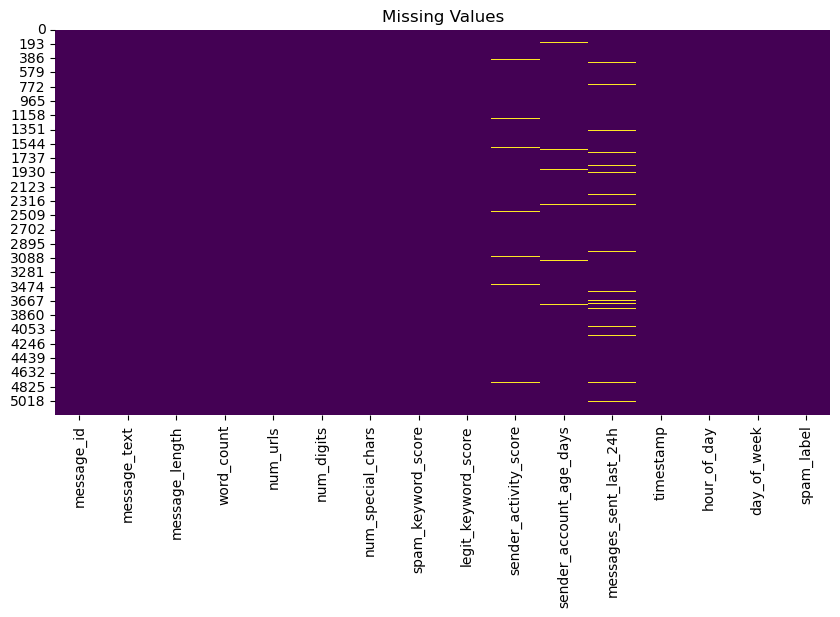

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


#### Task 6: identify inpute feature and target variable

In [12]:
y = df["spam_label"]
X = df.drop(columns=[
    "spam_label",
    "message_id",
    "message_text",
    "timestamp"
])

X.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5


In [13]:
df["spam_label"].value_counts()

spam_label
0    4227
1     973
Name: count, dtype: int64

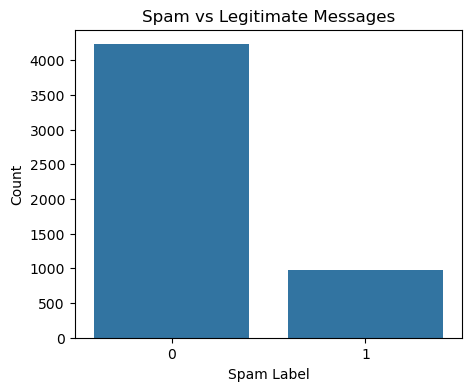

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(x="spam_label", data=df)

plt.title("Spam vs Legitimate Messages")
plt.xlabel("Spam Label")
plt.ylabel("Count")

plt.show()

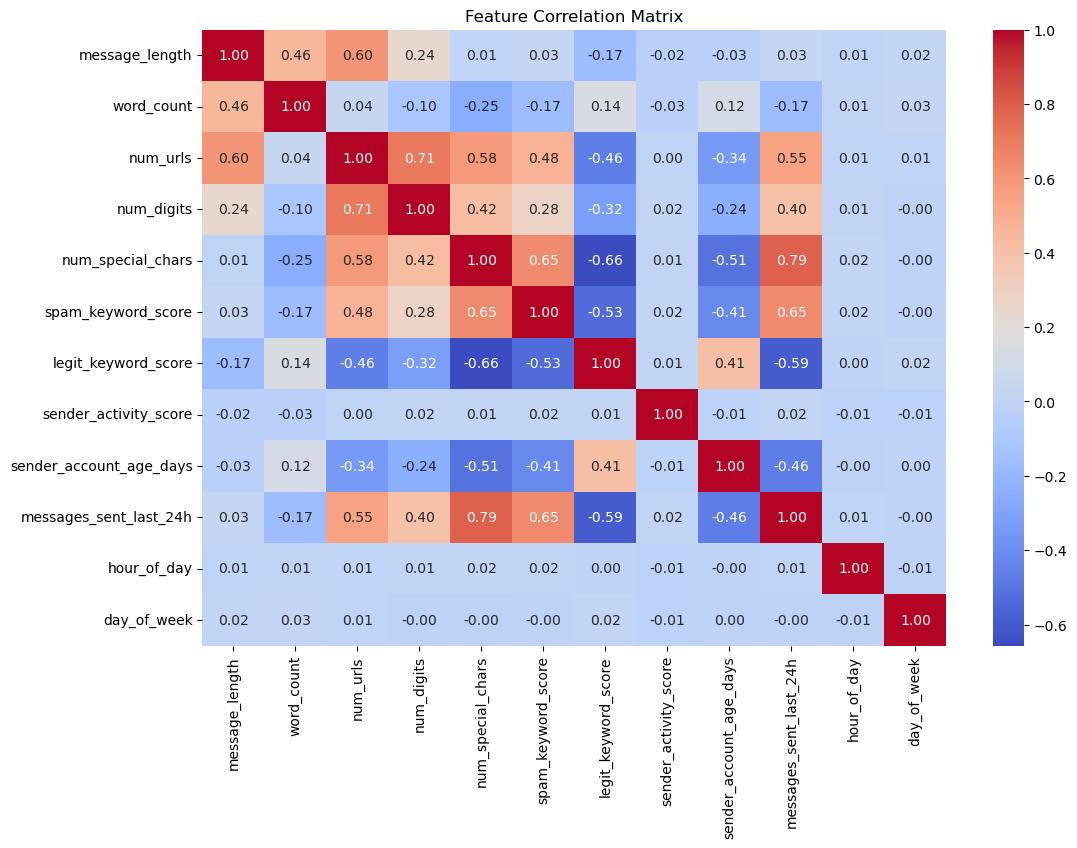

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

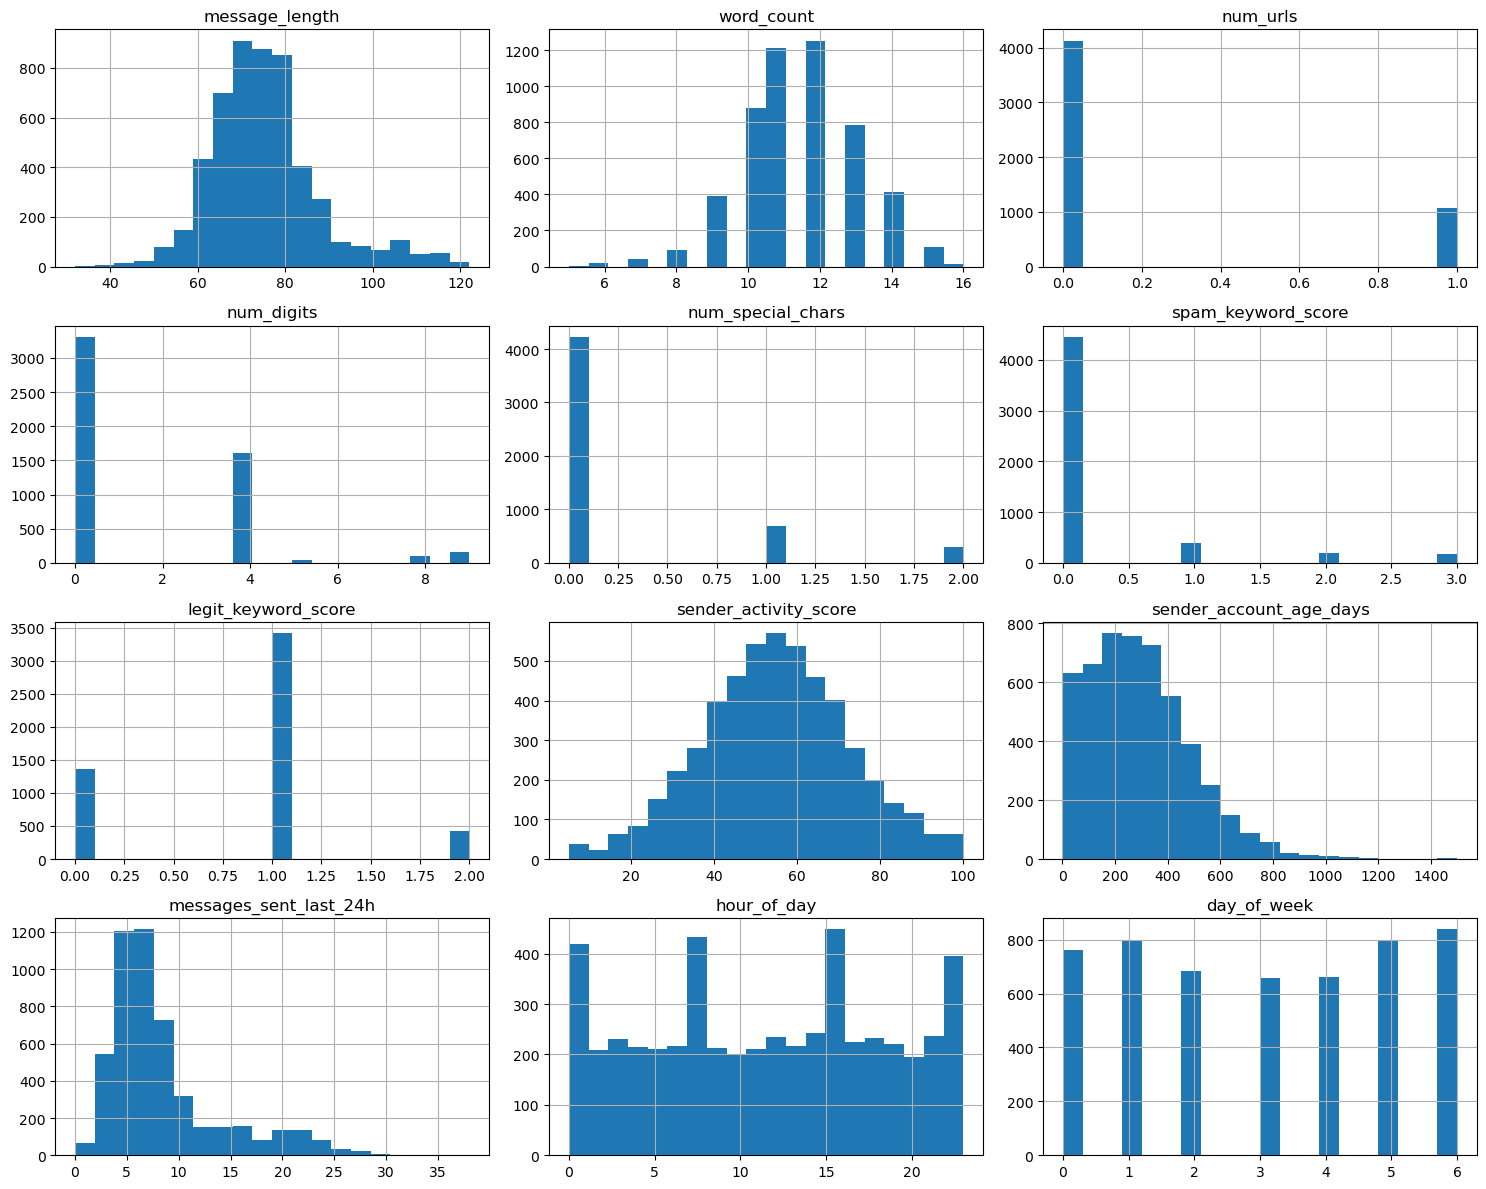

In [16]:
X.hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

#### task 7: perform basic daata preprocessning (scalling where required)

In [17]:
for c in X.columns:
    if X[c].dtype=='object':
        X[c]=X[c].fillna(X[c].mode()[0])
    else:
        X[c]=X[c].fillna(X[c].median())

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,1.924176,-0.284236,1.960029,0.959861,-0.446817,-0.364023,0.327518,0.100738,1.074541,-0.410937,-1.388086,-1.473518
1,-0.163476,0.337306,-0.510197,-0.696033,-0.446817,-0.364023,-1.468996,-2.183030,-0.470316,-1.501272,1.381247,-0.503730
2,-0.645242,0.958849,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.663473,0.642191,-0.410937,0.215212,0.950952
3,-0.886125,0.958849,-0.510197,0.959861,-0.446817,-0.364023,0.327518,-0.344596,-0.106511,-0.592660,1.672756,-0.503730
4,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.246685,2.039417,-0.229215,-0.076297,0.950952


#### task 8 :split the dataset into treining and testing sets

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [21]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (4160, 12)
Testing Features : (1040, 12)
Training Labels : (4160,)
Testing Labels : (1040,)


## part C : baseline model -k nearest neighbors

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

task 9:Knn

In [23]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski'
)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred = knn.predict(X_test)

y_prob = knn.predict_proba(X_test)[:,1]

In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC-AUC :", roc)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC-AUC : 1.0


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



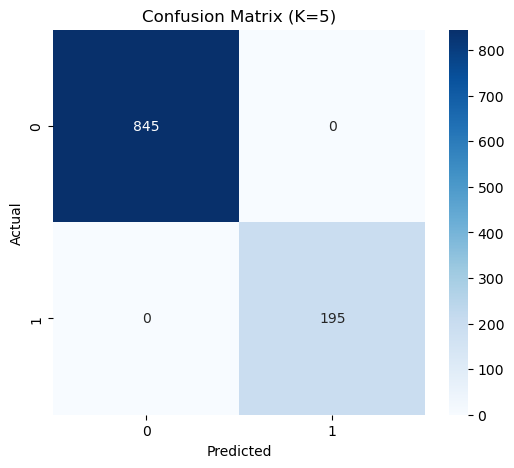

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (K=5)")

plt.show()

### task 10: experiment with diffrent values

In [28]:
knn_ = KNeighborsClassifier(
    n_neighbors=10,
    metric='minkowski'
)

knn_.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
y_pred = knn_.predict(X_test)

y_prob = knn_.predict_proba(X_test)[:,1]

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC-AUC :", roc)

Accuracy : 0.9990384615384615
Precision : 1.0
Recall : 0.9948717948717949
F1 Score : 0.9974293059125964
ROC-AUC : 1.0


In [31]:
k_values = range(1,21)

accuracy_scores = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    accuracy_scores.append(
        accuracy_score(y_test,pred)
    )

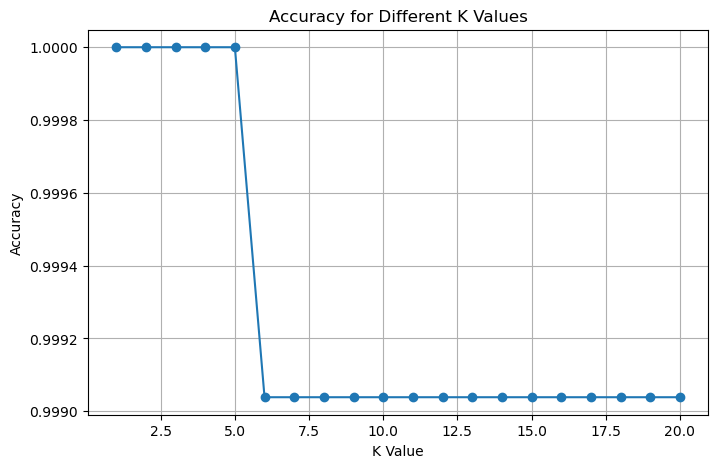

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracy_scores,
    marker='o'
)

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Accuracy for Different K Values")

plt.grid()

plt.show()

In [33]:
best_k = k_values[np.argmax(accuracy_scores)]

best_accuracy = max(accuracy_scores)

print("Best K :", best_k)

print("Best Accuracy :", best_accuracy)

Best K : 1
Best Accuracy : 1.0


In [34]:
metrics = [
    "euclidean",
    "manhattan",
    "minkowski"
]

results = []

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    pre = precision_score(y_test,pred)

    rec = recall_score(y_test,pred)

    f1 = f1_score(y_test,pred)

    results.append([metric,acc,pre,rec,f1])

In [35]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Metric",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison

,Metric,Accuracy,Precision,Recall,F1 Score
0,euclidean,1.0,1.0,1.0,1.0
1,manhattan,1.0,1.0,1.0,1.0
2,minkowski,1.0,1.0,1.0,1.0


In [36]:
misclassified = X_test.copy()

misclassified["Actual"] = y_test.values

misclassified["Predicted"] = y_pred

errors = misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

print("Total Misclassified Messages :", len(errors))

Total Misclassified Messages : 1


In [37]:
errors.head(10)

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,Actual,Predicted
905,-1.046714,0.958849,-0.510197,-0.696033,1.387001,-0.364023,-1.468996,2.093326,-1.466828,-0.229215,1.527001,-0.988624,1,0


In [38]:
misclassified_messages = df.loc[errors.index, ["message_text", "spam_label"]]

misclassified_messages["Predicted"] = errors["Predicted"].values

misclassified_messages.head(10)

,message_text,spam_label,Predicted
905,You are eligible for a refund of a brand new p...,1,0


In [39]:
performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

performance

,Metric,Value
0,Accuracy,0.999038
1,Precision,1.000000
2,Recall,0.994872
3,F1 Score,1.000000
4,ROC-AUC,1.000000


## part D : support vector machine classifier

In [40]:
from sklearn.svm import SVC

#### task 13: support vector machine classifire

In [41]:
svm_linear = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_linear.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
y_pred_linear = svm_linear.predict(X_test)

y_prob_linear = svm_linear.predict_proba(X_test)[:,1]

In [43]:
accuracy = accuracy_score(y_test, y_pred_linear)
precision = precision_score(y_test, y_pred_linear)
recall = recall_score(y_test, y_pred_linear)
f1 = f1_score(y_test, y_pred_linear)
roc = roc_auc_score(y_test, y_prob_linear)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :", roc)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0


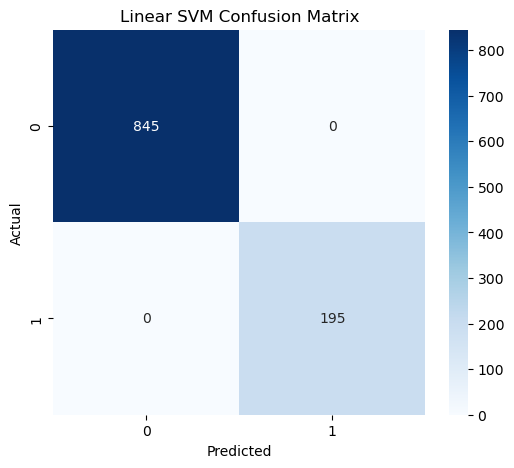

In [44]:
cm = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")

plt.show()

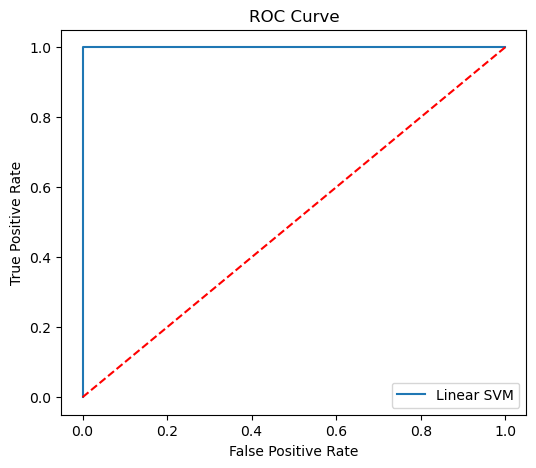

In [45]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_linear)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Linear SVM")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [46]:
print("Support Vectors per Class:")

print(svm_linear.n_support_)

print("Total Support Vectors:")

print(svm_linear.support_vectors_.shape[0])

Support Vectors per Class:
[5 5]
Total Support Vectors:
10


In [47]:
svm_rbf = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [48]:
pred_rbf = svm_rbf.predict(X_test)

prob_rbf = svm_rbf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred_rbf))

print("Precision :", precision_score(y_test,pred_rbf))

print("Recall :", recall_score(y_test,pred_rbf))

print("F1 :", f1_score(y_test,pred_rbf))

print("ROC :", roc_auc_score(y_test,prob_rbf))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 : 1.0
ROC : 1.0


In [49]:
svm_poly = SVC(
    kernel='poly',
    degree=3,
    probability=True,
    random_state=42
)

svm_poly.fit(X_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [50]:
pred_poly = svm_poly.predict(X_test)

prob_poly = svm_poly.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred_poly))

print("Precision :", precision_score(y_test,pred_poly))

print("Recall :", recall_score(y_test,pred_poly))

print("F1 :", f1_score(y_test,pred_poly))

print("ROC :", roc_auc_score(y_test,prob_poly))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 : 1.0
ROC : 1.0


In [51]:
results = pd.DataFrame({

    "Kernel":[
        "Linear",
        "RBF",
        "Polynomial"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_linear),
        accuracy_score(y_test,pred_rbf),
        accuracy_score(y_test,pred_poly)
    ],

    "Precision":[
        precision_score(y_test,y_pred_linear),
        precision_score(y_test,pred_rbf),
        precision_score(y_test,pred_poly)
    ],

    "Recall":[
        recall_score(y_test,y_pred_linear),
        recall_score(y_test,pred_rbf),
        recall_score(y_test,pred_poly)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_linear),
        f1_score(y_test,pred_rbf),
        f1_score(y_test,pred_poly)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_linear),
        roc_auc_score(y_test,prob_rbf),
        roc_auc_score(y_test,prob_poly)
    ]

})

results

,Kernel,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Linear,1.0,1.0,1.0,1.0,1.0
1,RBF,1.0,1.0,1.0,1.0,1.0
2,Polynomial,1.0,1.0,1.0,1.0,1.0


## Part E – Naive Bayes Classifier & Probability

#### Task 16: Implement Naive Bayes Classifier

In [52]:
from sklearn.naive_bayes import GaussianNB

In [53]:
nb = GaussianNB()

nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [54]:
y_pred_nb = nb.predict(X_test)

y_prob_nb = nb.predict_proba(X_test)[:,1]

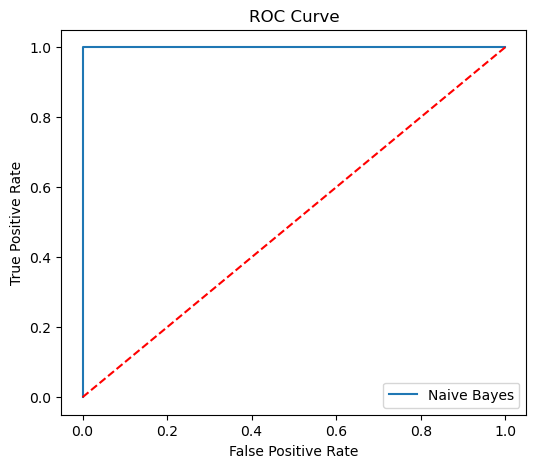

In [55]:
fpr,tpr,threshold = roc_curve(y_test,y_prob_nb)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Naive Bayes")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [56]:
prior = y_train.value_counts(normalize=True)

print("Prior Probabilities")

print(prior)

Prior Probabilities
spam_label
0    0.812981
1    0.187019
Name: proportion, dtype: float64


In [57]:
train_data = X_train.copy()

train_data["spam_label"] = y_train.values

train_data["has_url"] = (train_data["num_urls"] > 0).astype(int)

In [58]:
p_url_given_spam = (
    train_data[
        (train_data["spam_label"]==1) &
        (train_data["has_url"]==1)
    ].shape[0]
    /
    train_data[
        train_data["spam_label"]==1
    ].shape[0]
)

p_url_given_legit = (
    train_data[
        (train_data["spam_label"]==0) &
        (train_data["has_url"]==1)
    ].shape[0]
    /
    train_data[
        train_data["spam_label"]==0
    ].shape[0]
)

print("P(URL | Spam) =",p_url_given_spam)

print("P(URL | Legitimate) =",p_url_given_legit)

P(URL | Spam) = 0.7442159383033419
P(URL | Legitimate) = 0.07983441750443525


In [59]:
p_spam = prior[1]

p_legit = prior[0]

p_url = train_data["has_url"].mean()

posterior = (
    p_url_given_spam * p_spam
)/p_url

print("P(Spam | URL) =",posterior)

P(Spam | URL) = 0.6819787985865725


In [60]:
sample = X_test.iloc[[0]]

sample

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
799,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.543575,-0.074875,-0.410937,1.235492,-0.50373


In [61]:
prediction = nb.predict(sample)

probability = nb.predict_proba(sample)

print("Prediction :",prediction)

print("Probability :",probability)

Prediction : [0]
Probability : [[1. 0.]]


In [62]:
comparison = pd.DataFrame({

    "Class":[
        "Legitimate",
        "Spam"
    ],

    "Model Probability":probability[0]

})

comparison

,Class,Model Probability
0,Legitimate,1.0
1,Spam,0.0


In [63]:
performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

performance

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC-AUC,1.0


In [64]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],



    "Naive Bayes":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

comparison

,Metric,Naive Bayes
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC-AUC,1.0


## Part F – Model Comparison & Evaluation

In [65]:
# KNN Metrics
knn_accuracy = accuracy_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred)
knn_recall = recall_score(y_test, y_pred)
knn_f1 = f1_score(y_test, y_pred)
knn_roc = roc_auc_score(y_test, y_prob)

# SVM Metrics
svm_accuracy = accuracy_score(y_test, y_pred_linear)
svm_precision = precision_score(y_test, y_pred_linear)
svm_recall = recall_score(y_test, y_pred_linear)
svm_f1 = f1_score(y_test, y_pred_linear)
svm_roc = roc_auc_score(y_test, y_prob_linear)

# Naive Bayes Metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_roc = roc_auc_score(y_test, y_prob_nb)

Task 20: Evaluate All Models

In [66]:
comparison = pd.DataFrame({

    "Model":[
        "KNN",
        "SVM",
        "Naive Bayes"
    ],

    "Accuracy":[
        knn_accuracy,
        svm_accuracy,
        nb_accuracy
    ],

    "Precision":[
        knn_precision,
        svm_precision,
        nb_precision
    ],

    "Recall":[
        knn_recall,
        svm_recall,
        nb_recall
    ],

    "F1 Score":[
        knn_f1,
        svm_f1,
        nb_f1
    ],

    "ROC-AUC":[
        knn_roc,
        svm_roc,
        nb_roc
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.999038,1.0,0.994872,0.997429,1.0
1,SVM,1.000000,1.0,1.000000,1.000000,1.0
2,Naive Bayes,1.000000,1.0,1.000000,1.000000,1.0


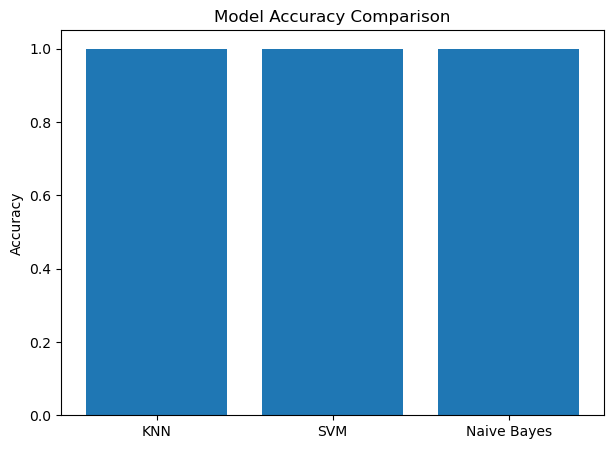

In [68]:
plt.figure(figsize=(7,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [75]:
best_accuracy = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_accuracy)

Model        SVM
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
ROC-AUC      1.0
Name: 1, dtype: object


In [74]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.999,1.0,0.9949,0.9974,1.0
1,SVM,1.000,1.0,1.0000,1.0000,1.0
2,Naive Bayes,1.000,1.0,1.0000,1.0000,1.0


Task 22: Identify Best Model

In [76]:
precision_model = comparison.loc[
    comparison["Precision"].idxmax(),
    "Model"
]

print("Best Model for High Precision:", precision_model)

Best Model for High Precision: KNN


In [77]:
overall_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

print("Best Overall Model:", overall_model)

Best Overall Model: SVM


## Part G – Final Analysis & Reporting

In [79]:
comparison.style.highlight_max(
    color="blue",
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.999000,1.000000,0.994900,0.997400,1.000000
1,SVM,1.000000,1.000000,1.000000,1.000000,1.000000
2,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000


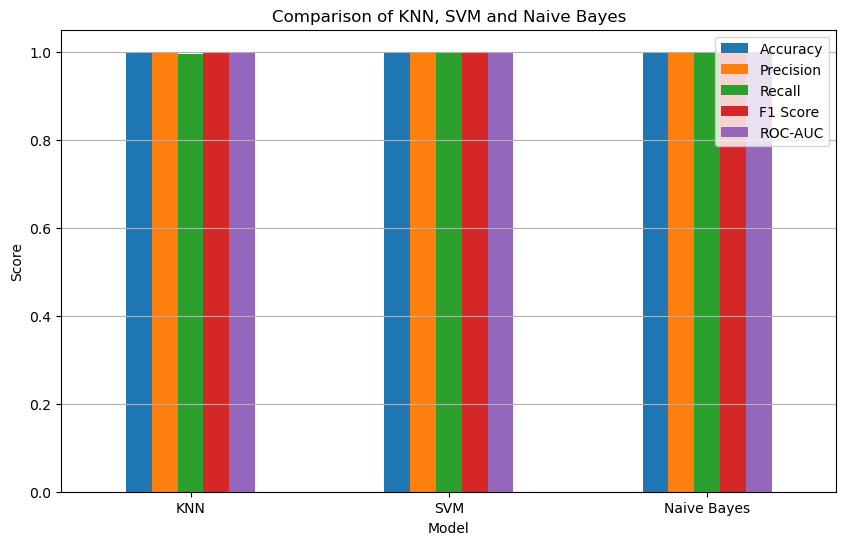

In [73]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of KNN, SVM and Naive Bayes")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()